# Valoración Económica de Praderas Marinas en Costa Rica

## Descripción
Este notebook proporciona un análisis completo de la valoración socioeconómica de los ecosistemas de praderas marinas (pastos marinos), incluyendo:

- **Valoración Económica**: Servicios ecosistémicos y beneficios monetarios
- **Análisis Sociológico**: Percepciones y conocimiento comunitario
- **Análisis de Sentimiento**: Evaluación de respuestas cualitativas
- **Análisis Estadístico**: Relaciones entre variables

## Ecosistemas de Praderas Marinas

### ¿Qué son?
Las praderas marinas son comunidades de plantas acuáticas enraizadas que crecen en fondos marinos someros. Incluyen especies como la zostera marina (Zostera marina) y la posidonia.

### Servicios Ecosistémicos
1. **Provisión de Alimentos**: Hábitat para peces comerciales
2. **Regulación**: Estabilización costera, filtración de agua
3. **Soporte**: Refugio y área de crianza para fauna marina
4. **Cultural**: Turismo, recreación, investigación científica

### Valor Económico
- Pesca sostenible: Ingresos directos
- Turismo: Buceo, snorkel, ecoturismo
- Servicios de regulación: Reducción de erosión, mejora de calidad de agua


In [1]:
import os
os.system('pip install wordcloud nltk textblob -q')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
import nltk
import warnings

warnings.filterwarnings('ignore')

# Descargar recursos NLTK
print("Descargando recursos NLTK...")
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

print("✓ Configuración completada")

# Configuración
np.random.seed(42)
RANDOM_STATE = 42
sns.set_style("whitegrid")


Descargando recursos NLTK...
✓ Configuración completada


[nltk_data] Error loading punkt: <urlopen error Tunnel connection
[nltk_data]     failed: 403 Forbidden>
[nltk_data] Error loading stopwords: <urlopen error Tunnel connection
[nltk_data]     failed: 403 Forbidden>


In [2]:
# Generación de Datos Simulados

def generar_datos_simulados(n=100, random_state=42):
    """Genera datos simulados de evaluación de praderas marinas.

    Args:
        n (int): Número de comunidades a simular
        random_state (int): Semilla para reproducibilidad

    Returns:
        pd.DataFrame: Datos con variables ecológicas, económicas y sociales
    """
    rng = np.random.default_rng(random_state)

    data = {
        # Variables Ecológicas
        'Cobertura_Pastos_Marinos': rng.uniform(50, 100, n),  # en %
        'Biomasa': rng.uniform(100, 500, n),  # en g/m²
        'Diversidad_Especies': rng.uniform(1, 3.5, n),  # Índice Shannon
        'Profundidad': rng.uniform(1, 15, n),  # en metros

        # Variables Económicas
        'Ingresos_Pesca': rng.uniform(5000, 25000, n),  # en $ USD
        'Ingresos_Turismo': rng.uniform(8000, 60000, n),  # en $ USD
        'Valor_Servicios_Ecosistemicos': rng.uniform(30000, 150000, n),  # en $ USD
        'Costo_Conservacion': rng.uniform(2000, 15000, n),  # en $ USD

        # Variables Sociales
        'Nivel_Conocimiento': rng.integers(1, 6, n),  # Escala Likert 1-5
        'Percepcion_Valor': rng.integers(1, 6, n),  # Escala Likert 1-5
        'Participacion_Conservacion': rng.choice([0, 1], n),  # Sí/No
        'Confianza_Instituciones': rng.integers(1, 6, n),  # Escala Likert

        # Variables de Gestión
        'Eficacia_Conservacion': rng.integers(1, 6, n),  # Escala Likert 1-5
        'Participacion_Comunitaria': rng.uniform(10, 95, n),  # en %
        'Apoyo_Gubernamental': rng.uniform(1, 10, n),  # Número de proyectos
    }

    return pd.DataFrame(data)

# Generar datos
df = generar_datos_simulados(n=120, random_state=RANDOM_STATE)

print(f"Base de datos generada: {df.shape[0]} observaciones, {df.shape[1]} variables")
print(f"\nPrimeras filas:")
display(df.head())

print(f"\nEstadísticas descriptivas:")
display(df.describe())


Base de datos generada: 120 observaciones, 15 variables

Primeras filas:


,Cobertura_Pastos_Marinos,Biomasa,Diversidad_Especies,Profundidad,Ingresos_Pesca,Ingresos_Turismo,Valor_Servicios_Ecosistemicos,Costo_Conservacion,Nivel_Conocimiento,Percepcion_Valor,Participacion_Conservacion,Confianza_Instituciones,Eficacia_Conservacion,Participacion_Comunitaria,Apoyo_Gubernamental
0,88.697802,333.639188,3.073572,14.037307,13175.662189,32830.305429,91527.847716,2162.108413,2,2,1,4,1,13.754884,4.879687
1,71.943922,359.938641,2.992043,2.676270,9352.570534,47594.493286,81956.699144,12348.371232,3,5,0,2,3,44.107522,1.323090
2,92.929896,133.777728,1.581602,2.639450,16766.124968,54973.049342,34301.130170,8762.990872,5,4,0,2,4,37.534617,5.811407
3,84.868401,266.322961,2.326924,2.227926,11340.818226,45476.189229,145172.942680,7303.498595,3,4,1,4,3,90.634867,9.941887
4,54.708867,116.645670,2.515040,10.210086,5721.196686,58086.983625,42360.322096,3222.935520,2,2,1,4,2,59.033181,9.628368



Estadísticas descriptivas:


,Cobertura_Pastos_Marinos,Biomasa,Diversidad_Especies,Profundidad,Ingresos_Pesca,Ingresos_Turismo,Valor_Servicios_Ecosistemicos,Costo_Conservacion,Nivel_Conocimiento,Percepcion_Valor,Participacion_Conservacion,Confianza_Instituciones,Eficacia_Conservacion,Participacion_Comunitaria,Apoyo_Gubernamental
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.00000,120.00000,120.000000,120.000000,120.000000,120.000000
mean,74.935627,294.981925,2.239441,8.069678,14860.239644,36469.747856,82956.390996,8638.599251,2.991667,3.20000,0.45000,2.908333,2.766667,52.629894,5.662370
std,13.687091,120.452178,0.702765,4.300545,5517.326510,15237.660158,35806.508238,3831.085275,1.463826,1.32589,0.49958,1.466694,1.424476,23.856362,2.761626
min,50.368113,105.574515,1.052870,1.076018,5146.289126,8234.006497,30147.967501,2162.108413,1.000000,1.00000,0.00000,1.000000,1.000000,10.392598,1.316584
25%,63.532433,179.576162,1.612665,3.756790,10783.947135,23562.215834,50529.587007,5186.863617,2.000000,2.00000,0.00000,2.000000,1.000000,37.284414,3.047123
50%,73.516300,296.939563,2.296068,8.429421,14929.586050,37563.109247,81035.964483,8409.744069,3.000000,3.00000,0.00000,3.000000,3.000000,51.456014,5.607769
75%,86.398003,401.447155,2.919229,11.849063,19072.533813,49204.870538,112286.114997,12123.867878,4.000000,4.00000,1.00000,4.000000,4.000000,71.897029,8.253920
max,98.781118,496.950226,3.448927,14.987466,24909.289452,59934.655243,149170.149832,14799.391907,5.000000,5.00000,1.00000,5.000000,5.000000,93.482265,9.953334


ANÁLISIS DE SENTIMIENTO
Escala de Polaridad: -1 (muy negativo) a +1 (muy positivo)
Escala de Subjetividad: 0 (objetivo) a 1 (subjetivo)

Resultados:


,texto,polaridad,subjetividad
0,Las praderas marinas son absolutamente esencia...,0.000000,0.000000
1,He notado una degradación significativa en los...,0.000000,0.000000
2,"Sin estos ecosistemas, perderíamos importantes...",0.000000,0.000000
3,La conservación de las praderas marinas debe s...,0.033333,0.066667
4,"Aunque hay desafíos, existen oportunidades rea...",0.000000,0.000000
5,Estos ecosistemas proporcionan beneficios inca...,0.000000,0.000000
6,La falta de conciencia pública es un problema ...,0.000000,0.000000
7,Los proyectos comunitarios han mostrado result...,0.000000,0.000000



Polaridad Promedio: 0.0042
Subjetividad Promedio: 0.0083


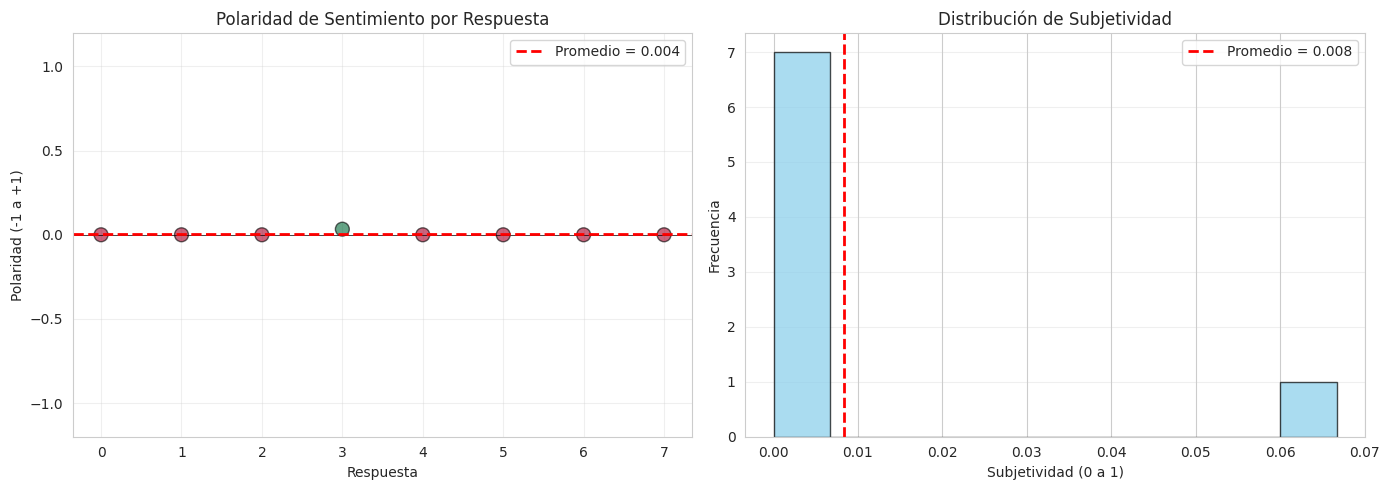


✓ Análisis de sentimiento completado


In [3]:
# Análisis de Sentimiento de Respuestas Cualitativas

respuestas_cualitativas = [
    "Las praderas marinas son absolutamente esenciales para nuestra economía local y biodiversidad marina.",
    "He notado una degradación significativa en los últimos años debido a actividades humanas.",
    "Sin estos ecosistemas, perderíamos importantes fuentes de ingreso para la comunidad.",
    "La conservación de las praderas marinas debe ser una prioridad política y social.",
    "Aunque hay desafíos, existen oportunidades reales de restauración y protección.",
    "Estos ecosistemas proporcionan beneficios incalculables que van más allá de valores monetarios.",
    "La falta de conciencia pública es un problema grave para la conservación.",
    "Los proyectos comunitarios han mostrado resultados prometedores en protección.",
]

def analizar_sentimiento(texto):
    """Analiza sentimiento positivo/negativo del texto.

    Args:
        texto (str): Texto a analizar

    Returns:
        dict: Diccionario con polarity y subjectivity
    """
    blob = TextBlob(texto)
    return {
        'texto': texto[:60] + '...',
        'polaridad': blob.sentiment.polarity,
        'subjetividad': blob.sentiment.subjectivity
    }

print("ANÁLISIS DE SENTIMIENTO")
print("=" * 70)
print("Escala de Polaridad: -1 (muy negativo) a +1 (muy positivo)")
print("Escala de Subjetividad: 0 (objetivo) a 1 (subjetivo)")
print("=" * 70)

sentimientos = [analizar_sentimiento(resp) for resp in respuestas_cualitativas]
df_sentimientos = pd.DataFrame(sentimientos)

print("\nResultados:")
display(df_sentimientos)

# Estadísticas de sentimiento
print(f"\nPolaridad Promedio: {df_sentimientos['polaridad'].mean():.4f}")
print(f"Subjetividad Promedio: {df_sentimientos['subjetividad'].mean():.4f}")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Polaridad
axes[0].scatter(range(len(df_sentimientos)), df_sentimientos['polaridad'],
               s=100, alpha=0.6, c=df_sentimientos['polaridad'], cmap='RdYlGn', edgecolors='black')
axes[0].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[0].axhline(df_sentimientos['polaridad'].mean(), color='red', linestyle='--', linewidth=2,
               label=f"Promedio = {df_sentimientos['polaridad'].mean():.3f}")
axes[0].set_title('Polaridad de Sentimiento por Respuesta')
axes[0].set_xlabel('Respuesta')
axes[0].set_ylabel('Polaridad (-1 a +1)')
axes[0].set_ylim(-1.2, 1.2)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Subjetividad
axes[1].hist(df_sentimientos['subjetividad'], bins=10, color='skyblue', alpha=0.7, edgecolor='black')
axes[1].axvline(df_sentimientos['subjetividad'].mean(), color='red', linestyle='--', linewidth=2,
               label=f"Promedio = {df_sentimientos['subjetividad'].mean():.3f}")
axes[1].set_title('Distribución de Subjetividad')
axes[1].set_xlabel('Subjetividad (0 a 1)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Análisis de sentimiento completado")


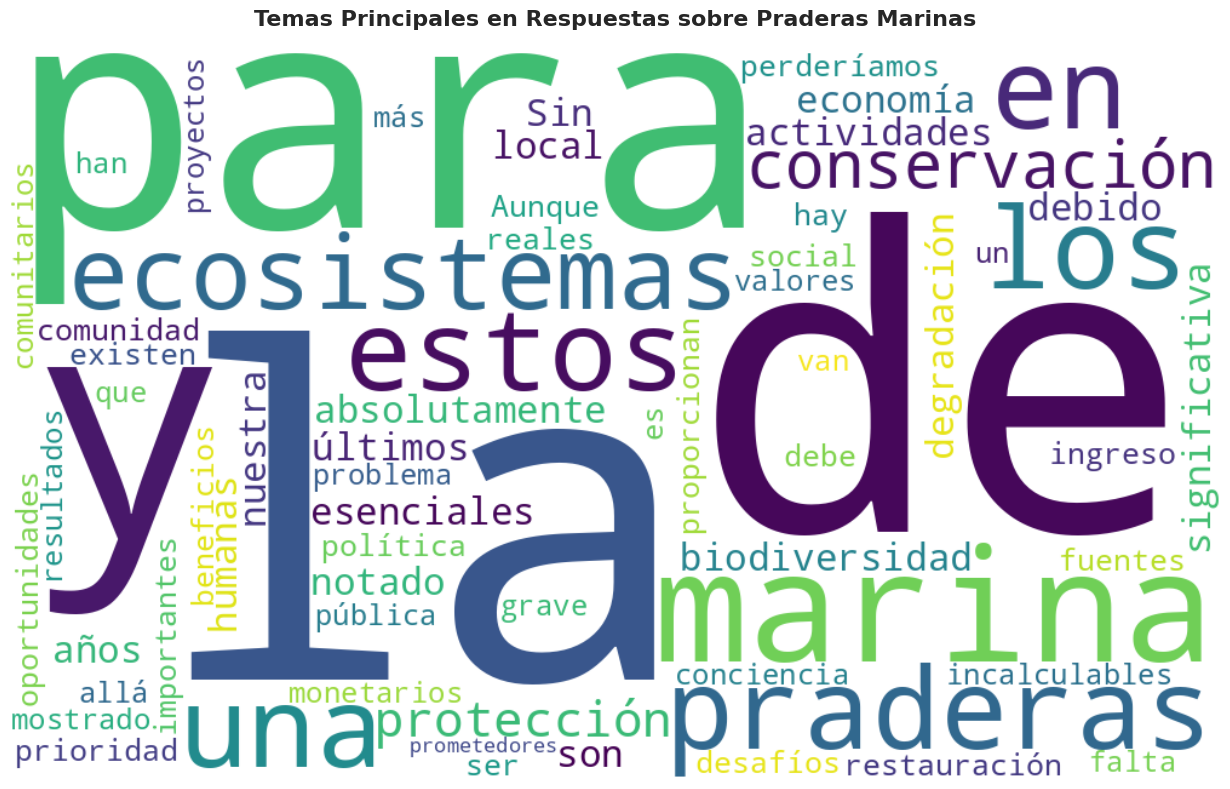

✓ Nube de palabras generada


In [4]:
# Nube de Palabras

def generar_nube_palabras(textos, titulo="Nube de Palabras"):
    """Genera una nube de palabras con manejo de errores.

    Args:
        textos (list): Lista de textos
        titulo (str): Título del gráfico
    """
    try:
        # Combinar textos
        texto_combinado = " ".join([str(t) for t in textos if pd.notna(t)])

        if len(texto_combinado.strip()) == 0:
            print("⚠ No hay texto para procesar")
            return

        # Generar nube
        wordcloud = WordCloud(
            width=1000,
            height=600,
            background_color='white',
            colormap='viridis',
            max_words=100,
            relative_scaling=0.5
        ).generate(texto_combinado)

        # Visualizar
        plt.figure(figsize=(14, 8))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(titulo, fontsize=16, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

        print("✓ Nube de palabras generada")

    except Exception as e:
        print(f"✗ Error generando nube de palabras: {e}")
        print("Continuando con análisis...")

# Generar nube
generar_nube_palabras(respuestas_cualitativas,
                     titulo="Temas Principales en Respuestas sobre Praderas Marinas")


ANÁLISIS ECOLÓGICO DE PRADERAS MARINAS


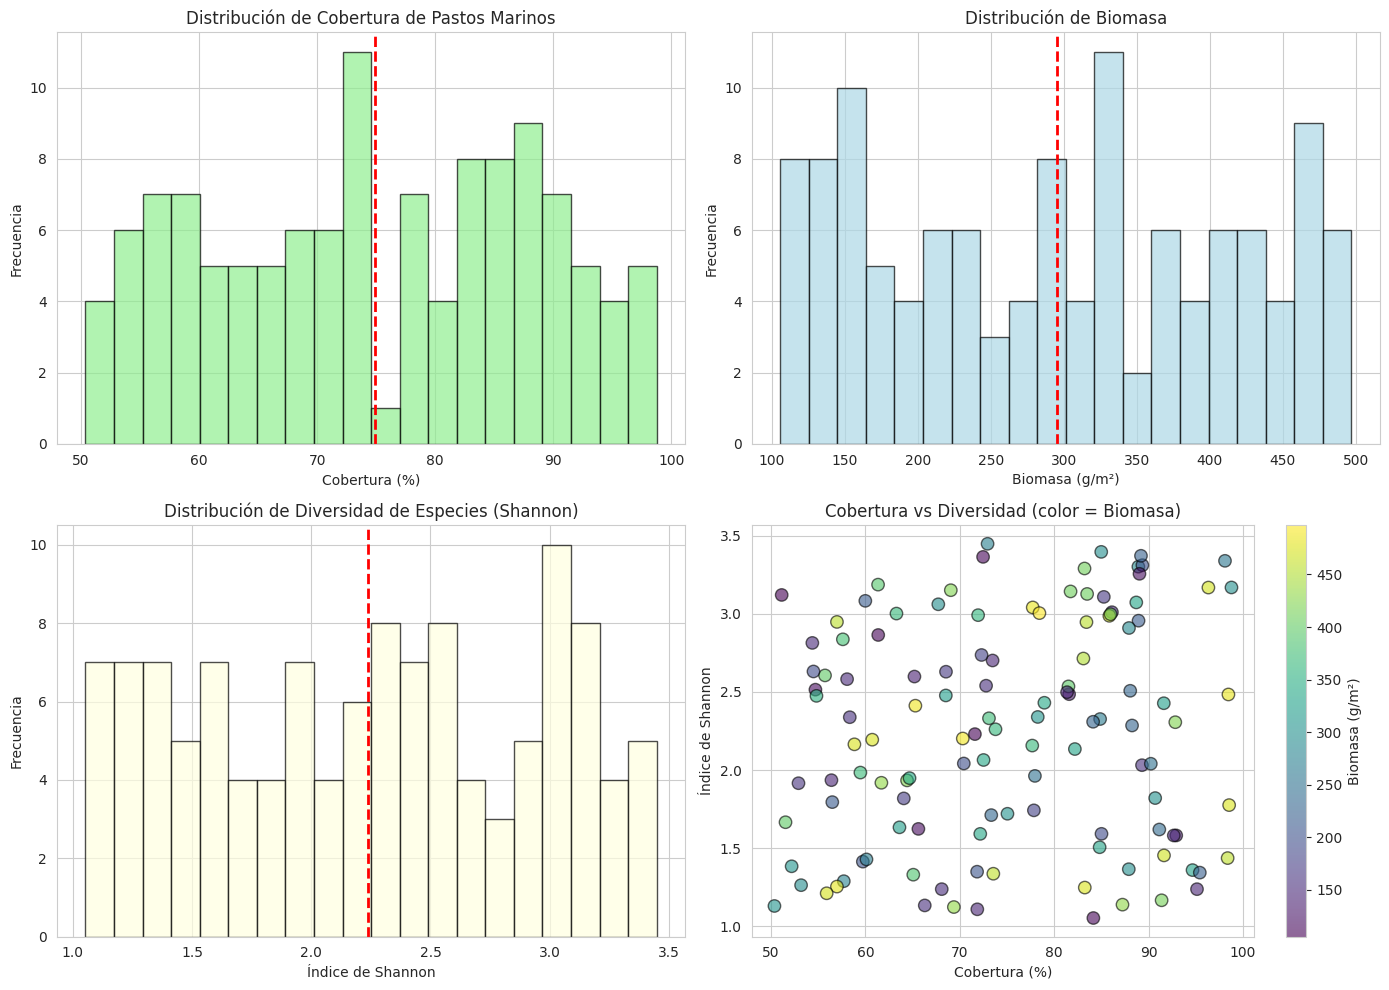


Estadísticas Ecológicas:
       Cobertura_Pastos_Marinos     Biomasa  Diversidad_Especies  Profundidad
count                120.000000  120.000000           120.000000   120.000000
mean                  74.935627  294.981925             2.239441     8.069678
std                   13.687091  120.452178             0.702765     4.300545
min                   50.368113  105.574515             1.052870     1.076018
25%                   63.532433  179.576162             1.612665     3.756790
50%                   73.516300  296.939563             2.296068     8.429421
75%                   86.398003  401.447155             2.919229    11.849063
max                   98.781118  496.950226             3.448927    14.987466


In [5]:
# Análisis Descriptivo: Variables Ecológicas

print("ANÁLISIS ECOLÓGICO DE PRADERAS MARINAS")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cobertura
axes[0, 0].hist(df['Cobertura_Pastos_Marinos'], bins=20, color='lightgreen', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Distribución de Cobertura de Pastos Marinos')
axes[0, 0].set_xlabel('Cobertura (%)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].axvline(df['Cobertura_Pastos_Marinos'].mean(), color='red', linestyle='--', linewidth=2)

# Biomasa
axes[0, 1].hist(df['Biomasa'], bins=20, color='lightblue', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Distribución de Biomasa')
axes[0, 1].set_xlabel('Biomasa (g/m²)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].axvline(df['Biomasa'].mean(), color='red', linestyle='--', linewidth=2)

# Diversidad
axes[1, 0].hist(df['Diversidad_Especies'], bins=20, color='lightyellow', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Distribución de Diversidad de Especies (Shannon)')
axes[1, 0].set_xlabel('Índice de Shannon')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].axvline(df['Diversidad_Especies'].mean(), color='red', linestyle='--', linewidth=2)

# Relación Cobertura vs Diversidad
axes[1, 1].scatter(df['Cobertura_Pastos_Marinos'], df['Diversidad_Especies'],
                  s=80, alpha=0.6, edgecolors='black', c=df['Biomasa'], cmap='viridis')
axes[1, 1].set_title('Cobertura vs Diversidad (color = Biomasa)')
axes[1, 1].set_xlabel('Cobertura (%)')
axes[1, 1].set_ylabel('Índice de Shannon')
cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
cbar.set_label('Biomasa (g/m²)')

plt.tight_layout()
plt.show()

print("\nEstadísticas Ecológicas:")
print(df[['Cobertura_Pastos_Marinos', 'Biomasa', 'Diversidad_Especies', 'Profundidad']].describe())


ANÁLISIS ECONÓMICO DE SERVICIOS ECOSISTÉMICOS


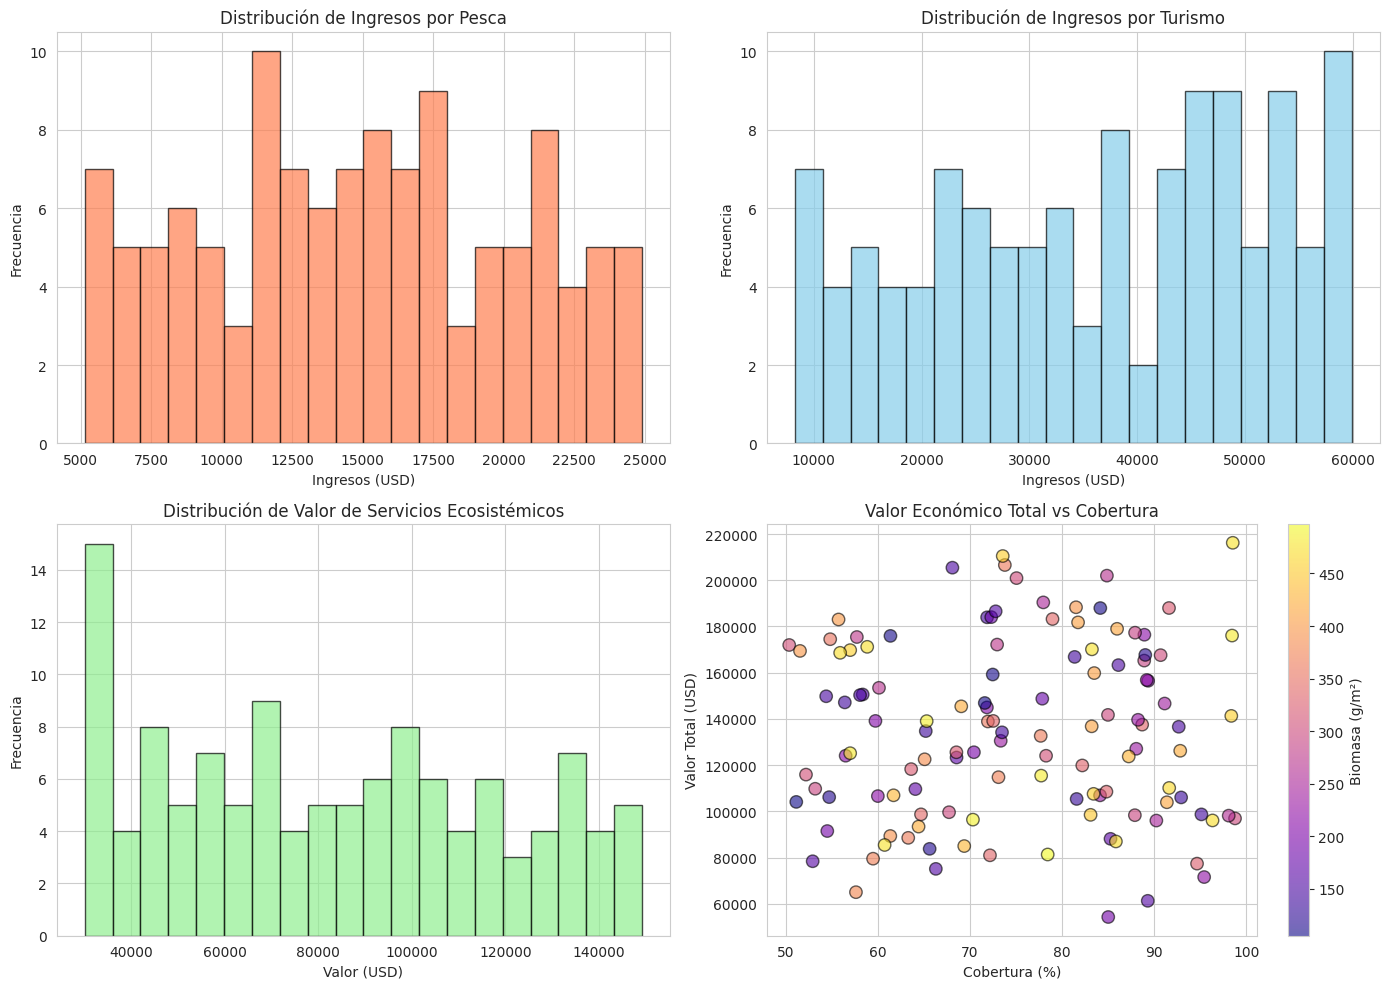


Correlación (Cobertura vs Valor Económico): 0.0277

Estadísticas Económicas (en USD):
       Ingresos_Pesca  Ingresos_Turismo  Valor_Servicios_Ecosistemicos  \
count      120.000000        120.000000                     120.000000   
mean     14860.239644      36469.747856                   82956.390996   
std       5517.326510      15237.660158                   35806.508238   
min       5146.289126       8234.006497                   30147.967501   
25%      10783.947135      23562.215834                   50529.587007   
50%      14929.586050      37563.109247                   81035.964483   
75%      19072.533813      49204.870538                  112286.114997   
max      24909.289452      59934.655243                  149170.149832   

          Valor_Neto  
count     120.000000  
mean   134286.378497  
std     38174.745517  
min     54303.253293  
25%    104064.043903  
50%    134474.729673  
75%    167912.183840  
max    216200.980409  


In [6]:
# Análisis Económico: Valoración de Servicios Ecosistémicos

print("ANÁLISIS ECONÓMICO DE SERVICIOS ECOSISTÉMICOS")
print("=" * 70)

# Crear variable de valor neto
df['Valor_Neto'] = df['Valor_Servicios_Ecosistemicos'] + df['Ingresos_Pesca'] + df['Ingresos_Turismo']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ingresos por Pesca
axes[0, 0].hist(df['Ingresos_Pesca'], bins=20, color='coral', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Distribución de Ingresos por Pesca')
axes[0, 0].set_xlabel('Ingresos (USD)')
axes[0, 0].set_ylabel('Frecuencia')

# Ingresos por Turismo
axes[0, 1].hist(df['Ingresos_Turismo'], bins=20, color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Distribución de Ingresos por Turismo')
axes[0, 1].set_xlabel('Ingresos (USD)')
axes[0, 1].set_ylabel('Frecuencia')

# Valor de Servicios Ecosistémicos
axes[1, 0].hist(df['Valor_Servicios_Ecosistemicos'], bins=20, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Distribución de Valor de Servicios Ecosistémicos')
axes[1, 0].set_xlabel('Valor (USD)')
axes[1, 0].set_ylabel('Frecuencia')

# Valor Total vs Cobertura
scatter = axes[1, 1].scatter(df['Cobertura_Pastos_Marinos'], df['Valor_Neto'],
                            s=80, alpha=0.6, c=df['Biomasa'], cmap='plasma', edgecolors='black')
axes[1, 1].set_title('Valor Económico Total vs Cobertura')
axes[1, 1].set_xlabel('Cobertura (%)')
axes[1, 1].set_ylabel('Valor Total (USD)')
cbar = plt.colorbar(scatter, ax=axes[1, 1])
cbar.set_label('Biomasa (g/m²)')

plt.tight_layout()
plt.show()

# Correlación Cobertura - Valor Económico
corr = df['Cobertura_Pastos_Marinos'].corr(df['Valor_Neto'])
print(f"\nCorrelación (Cobertura vs Valor Económico): {corr:.4f}")

print("\nEstadísticas Económicas (en USD):")
print(df[['Ingresos_Pesca', 'Ingresos_Turismo', 'Valor_Servicios_Ecosistemicos', 'Valor_Neto']].describe())


ANÁLISIS SOCIAL Y COMUNITARIO


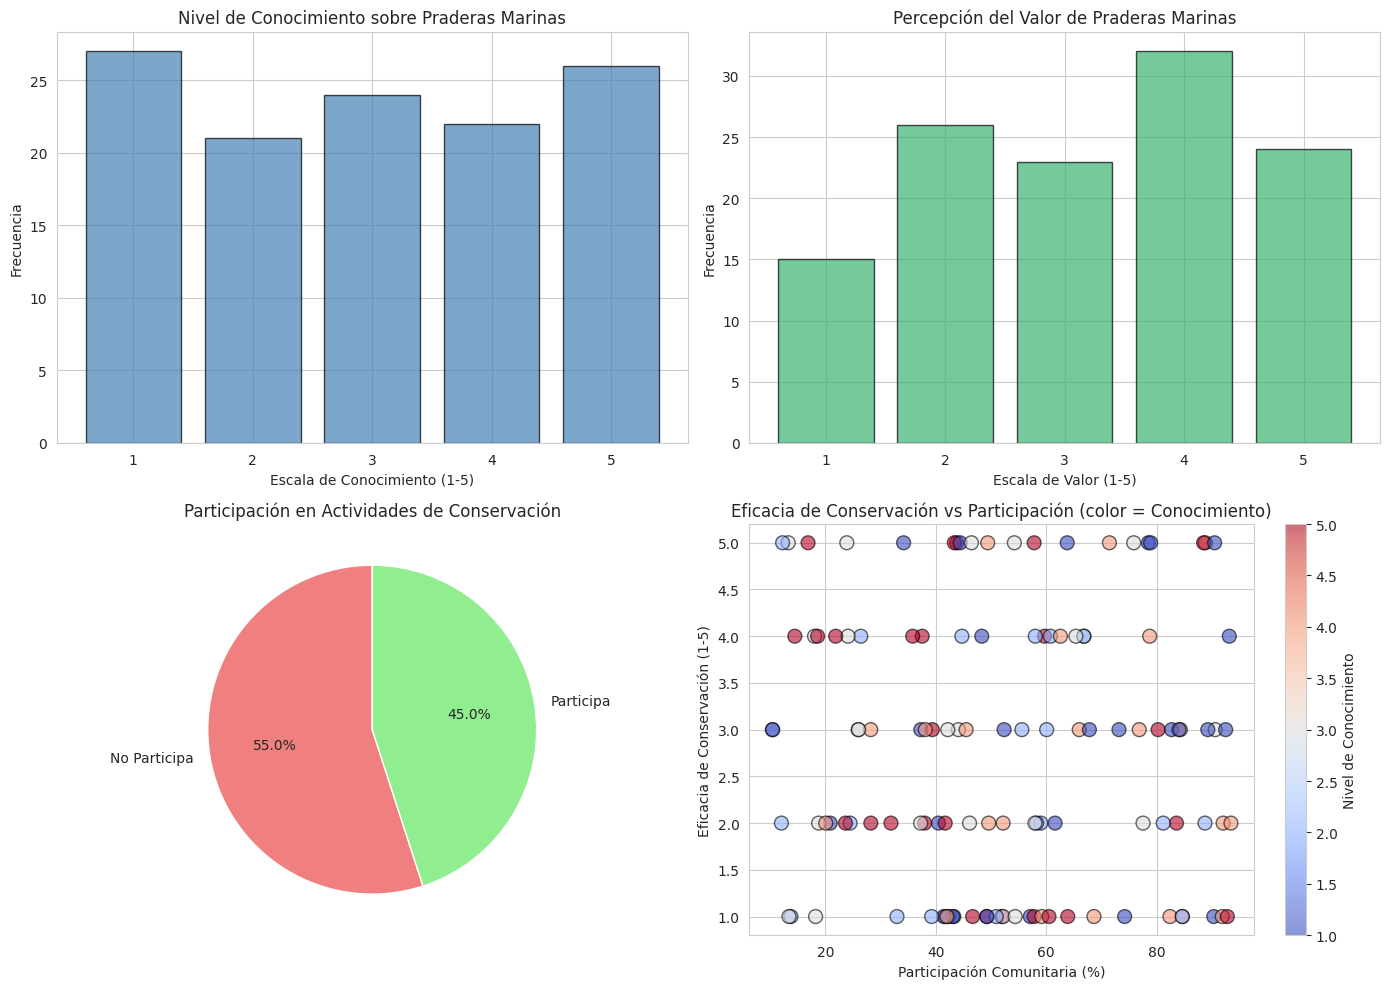


Participación en Conservación: 54 de 120 (45.0%)

Estadísticas Sociales:
       Nivel_Conocimiento  Percepcion_Valor  Eficacia_Conservacion  \
count          120.000000         120.00000             120.000000   
mean             2.991667           3.20000               2.766667   
std              1.463826           1.32589               1.424476   
min              1.000000           1.00000               1.000000   
25%              2.000000           2.00000               1.000000   
50%              3.000000           3.00000               3.000000   
75%              4.000000           4.00000               4.000000   
max              5.000000           5.00000               5.000000   

       Participacion_Comunitaria  
count                 120.000000  
mean                   52.629894  
std                    23.856362  
min                    10.392598  
25%                    37.284414  
50%                    51.456014  
75%                    71.897029  
max            

In [7]:
# Análisis Social: Percepciones y Participación Comunitaria

print("ANÁLISIS SOCIAL Y COMUNITARIO")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Conocimiento
conocimiento_counts = df['Nivel_Conocimiento'].value_counts().sort_index()
axes[0, 0].bar(conocimiento_counts.index, conocimiento_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Nivel de Conocimiento sobre Praderas Marinas')
axes[0, 0].set_xlabel('Escala de Conocimiento (1-5)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_xticks(range(1, 6))

# Percepción de Valor
percepcion_counts = df['Percepcion_Valor'].value_counts().sort_index()
axes[0, 1].bar(percepcion_counts.index, percepcion_counts.values, color='mediumseagreen', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Percepción del Valor de Praderas Marinas')
axes[0, 1].set_xlabel('Escala de Valor (1-5)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_xticks(range(1, 6))

# Participación en Conservación
participa = df['Participacion_Conservacion'].value_counts()
labels = ['No Participa', 'Participa']
colors = ['lightcoral', 'lightgreen']
axes[1, 0].pie(participa.values, labels=[labels[i] for i in participa.index], colors=colors,
              autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Participación en Actividades de Conservación')

# Eficacia de Conservación vs Participación Comunitaria
axes[1, 1].scatter(df['Participacion_Comunitaria'], df['Eficacia_Conservacion'],
                  s=100, alpha=0.6, c=df['Nivel_Conocimiento'], cmap='coolwarm', edgecolors='black')
axes[1, 1].set_title('Eficacia de Conservación vs Participación (color = Conocimiento)')
axes[1, 1].set_xlabel('Participación Comunitaria (%)')
axes[1, 1].set_ylabel('Eficacia de Conservación (1-5)')
cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
cbar.set_label('Nivel de Conocimiento')

plt.tight_layout()
plt.show()

print(f"\nParticipación en Conservación: {df['Participacion_Conservacion'].sum()} de {len(df)} ({df['Participacion_Conservacion'].mean()*100:.1f}%)")
print("\nEstadísticas Sociales:")
print(df[['Nivel_Conocimiento', 'Percepcion_Valor', 'Eficacia_Conservacion', 'Participacion_Comunitaria']].describe())


## Ejercicios para el Estudiante

### Ejercicio 1: Análisis de Correlaciones
Calcula la matriz de correlación entre:
- Cobertura de pastos y valor económico
- Nivel de conocimiento y participación
- Eficacia de conservación y apoyo gubernamental

¿Cuáles son las relaciones más fuertes?

### Ejercicio 2: Segmentación de Comunidades
Agrupa las observaciones por nivel de conocimiento y compara:
- Valor económico promedio
- Tasa de participación
- Eficacia de conservación percibida

¿Hay diferencias significativas?

### Ejercicio 3: Análisis de Rentabilidad de Conservación
Calcula para cada observación:
- Costo-beneficio: (Valor Total) / (Costo de Conservación)
- Identifica las praderas más rentables de conservar
- ¿Qué características tienen las más rentables?

---

**Nota**: Estos análisis pueden ser extendidos con técnicas de machine learning para predicción y clasificación.
